In [1]:
import sys
import os

from google.colab import drive
drive.mount("/content/drive", force_remount=True)


PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(sys.path[:3])
!ls "/content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing"

Mounted at /content/drive
['/content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing', '/content', '/env/python']
analytics   cv	  database    nlp	rag  visualization
clustering  data  evaluation  pipeline	ui


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt



BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing"
DATA_PATH = f"{BASE_DIR}/data/ads_with_strategies.csv"
FIG_DIR = f"{BASE_DIR}/paper_figures"

os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Loaded rows:", len(df))
print("Figure folder:", FIG_DIR)

Loaded rows: 2046
Figure folder: /content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing/paper_figures


1. diagram pipeline

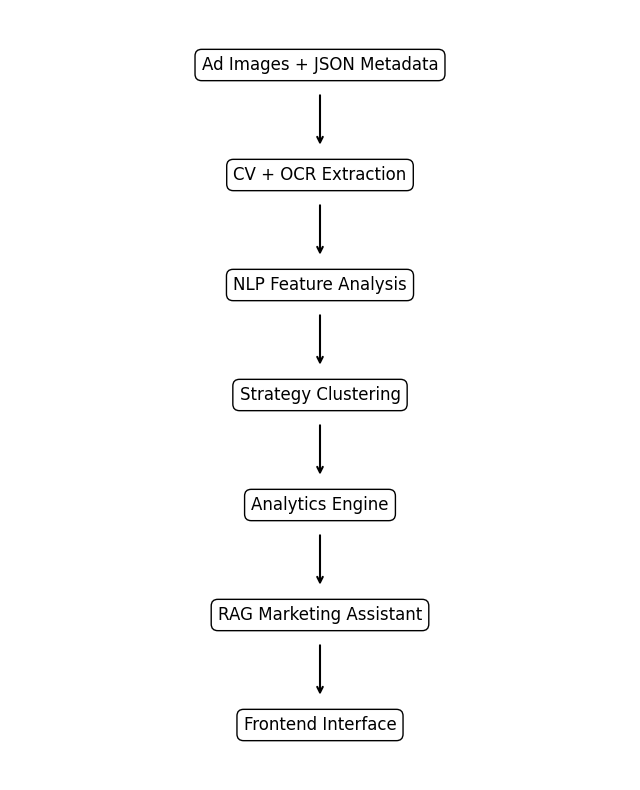

Saved: /content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing/paper_figures/pipeline_architecture.png


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))
ax.axis("off")

steps = [
    "Ad Images + JSON Metadata",
    "CV + OCR Extraction",
    "NLP Feature Analysis",
    "Strategy Clustering",
    "Analytics Engine",
    "RAG Marketing Assistant",
    "Frontend Interface"
]

y_positions = list(range(len(steps), 0, -1))

for y, step in zip(y_positions, steps):
    ax.text(
        0.5, y, step,
        ha="center", va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
    )

for i in range(len(y_positions) - 1):
    ax.annotate(
        "",
        xy=(0.5, y_positions[i+1] + 0.25),
        xytext=(0.5, y_positions[i] - 0.25),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.set_xlim(0, 1)
ax.set_ylim(0.5, len(steps) + 0.5)

pipeline_path = f"{FIG_DIR}/pipeline_architecture.png"
plt.savefig(pipeline_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pipeline_path)

2. strategy distribution bar chart

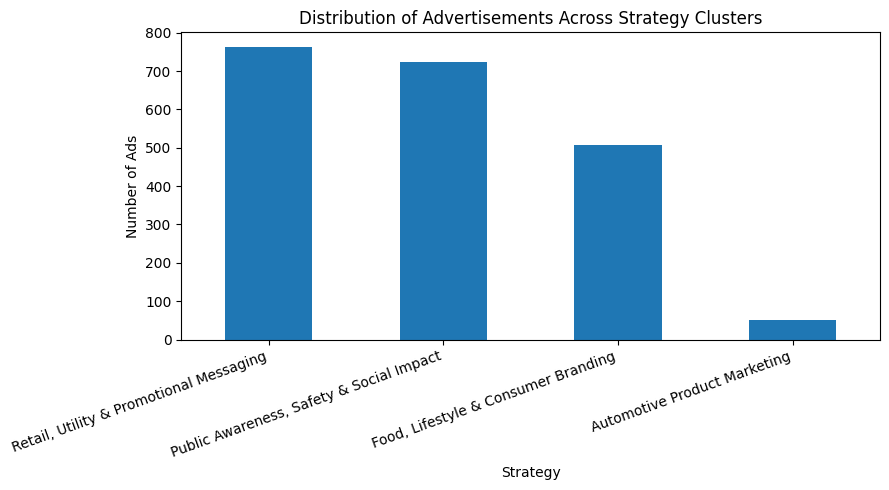

Saved: /content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing/paper_figures/strategy_distribution.png


In [4]:
strategy_counts = df["strategy"].value_counts()

plt.figure(figsize=(9, 5))
strategy_counts.plot(kind="bar")
plt.title("Distribution of Advertisements Across Strategy Clusters")
plt.xlabel("Strategy")
plt.ylabel("Number of Ads")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

strategy_dist_path = f"{FIG_DIR}/strategy_distribution.png"
plt.savefig(strategy_dist_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", strategy_dist_path)

3. industry vs. strategy

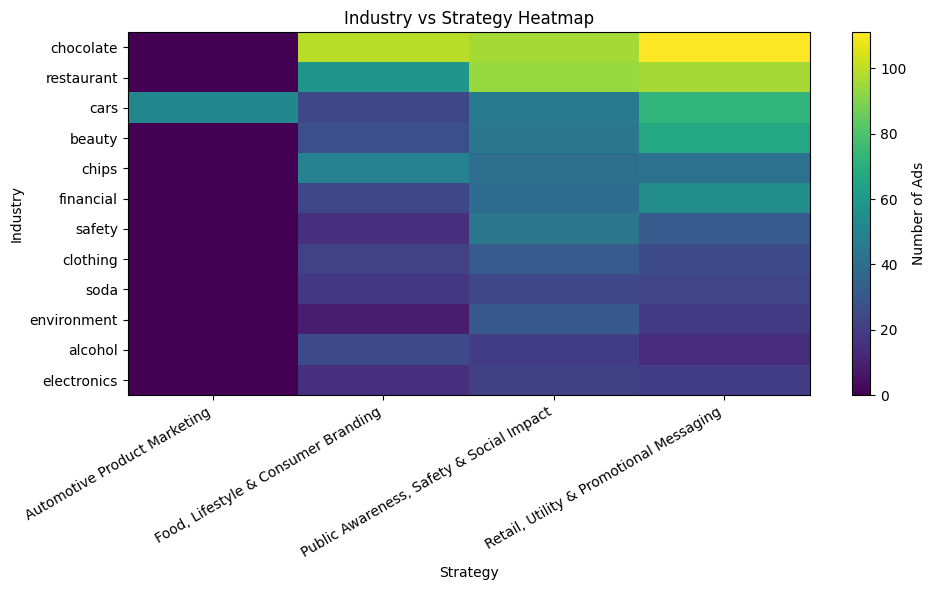

Saved: /content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing/paper_figures/industry_strategy_heatmap.png


In [5]:
cross_tab = pd.crosstab(df["competitor"], df["strategy"])

# optional: only show top industries so it is readable
top_industries = df["competitor"].value_counts().head(12).index
cross_tab = cross_tab.loc[top_industries]

plt.figure(figsize=(10, 6))
plt.imshow(cross_tab, aspect="auto")
plt.title("Industry vs Strategy Heatmap")
plt.xlabel("Strategy")
plt.ylabel("Industry")
plt.xticks(range(len(cross_tab.columns)), cross_tab.columns, rotation=30, ha="right")
plt.yticks(range(len(cross_tab.index)), cross_tab.index)
plt.colorbar(label="Number of Ads")
plt.tight_layout()

heatmap_path = f"{FIG_DIR}/industry_strategy_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", heatmap_path)

4. example assistant output figure

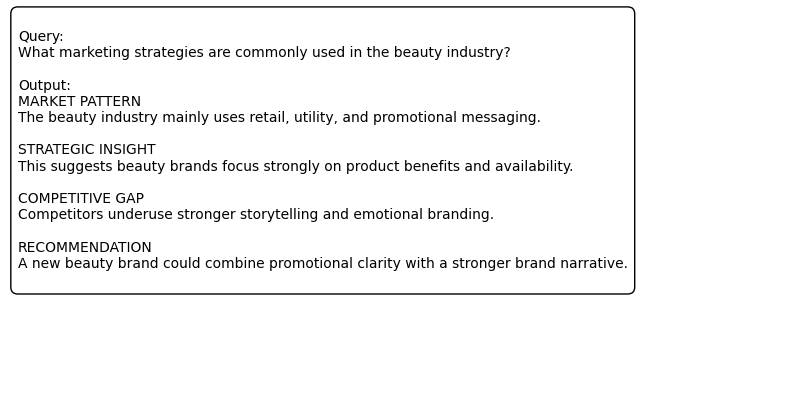

Saved: /content/drive/MyDrive/Colab Notebooks/intelligence_ai_marketing/paper_figures/assistant_example_output.png


In [6]:
example_text = """
Query:
What marketing strategies are commonly used in the beauty industry?

Output:
MARKET PATTERN
The beauty industry mainly uses retail, utility, and promotional messaging.

STRATEGIC INSIGHT
This suggests beauty brands focus strongly on product benefits and availability.

COMPETITIVE GAP
Competitors underuse stronger storytelling and emotional branding.

RECOMMENDATION
A new beauty brand could combine promotional clarity with a stronger brand narrative.
"""

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
ax.text(
    0.01, 0.99, example_text,
    va="top", ha="left", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white")
)

example_path = f"{FIG_DIR}/assistant_example_output.png"
plt.savefig(example_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", example_path)